In [ ]:
#import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import files

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)


In [ ]:
#load Dataset
uploaded = files.upload()

df = pd.read_excel(list(uploaded.keys())[0])

print("Dataset Shape:", df.shape)
print("\nFirst 5 Rows:")
display(df.head())

Saving Customer_Segmentation_Dataset_500 - Copy.xlsx to Customer_Segmentation_Dataset_500 - Copy.xlsx
Dataset Shape: (500, 6)

First 5 Rows:


,Customer_ID,Age,Annual_Income,Spending_Score,Purchases_Per_Month,Segment
0,C001,56,120402,80,10,High Value
1,C002,45,85155,40,11,Medium Value
2,C003,36,126540,72,13,High Value
3,C004,49,42539,18,2,Low Value
4,C005,28,81351,77,9,Medium Value


In [ ]:
print("\nDataset Information")
df.info()

print("\nMissing Values")
print(df.isnull().sum())

print("\nStatistical Summary")
display(df.describe())


Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Customer_ID          500 non-null    object
 1   Age                  500 non-null    int64 
 2   Annual_Income        500 non-null    int64 
 3   Spending_Score       500 non-null    int64 
 4   Purchases_Per_Month  500 non-null    int64 
 5   Segment              500 non-null    object
dtypes: int64(4), object(2)
memory usage: 23.6+ KB

Missing Values
Customer_ID            0
Age                    0
Annual_Income          0
Spending_Score         0
Purchases_Per_Month    0
Segment                0
dtype: int64

Statistical Summary


,Age,Annual_Income,Spending_Score,Purchases_Per_Month
count,500.000000,500.000000,500.00000,500.000000
mean,41.472000,84851.482000,58.92600,9.604000
std,13.778713,38153.197618,24.27697,5.162993
min,18.000000,20065.000000,1.00000,1.000000
25%,30.000000,52741.250000,41.00000,5.000000
50%,41.000000,83785.500000,63.00000,9.500000
75%,53.000000,117778.750000,77.00000,13.000000
max,65.000000,149620.000000,100.00000,20.000000


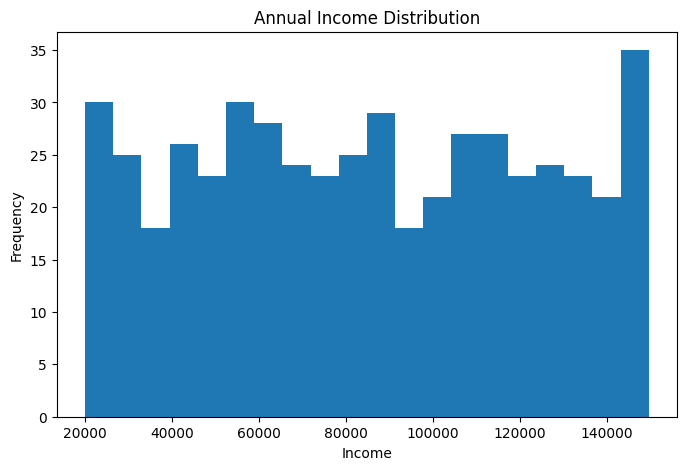

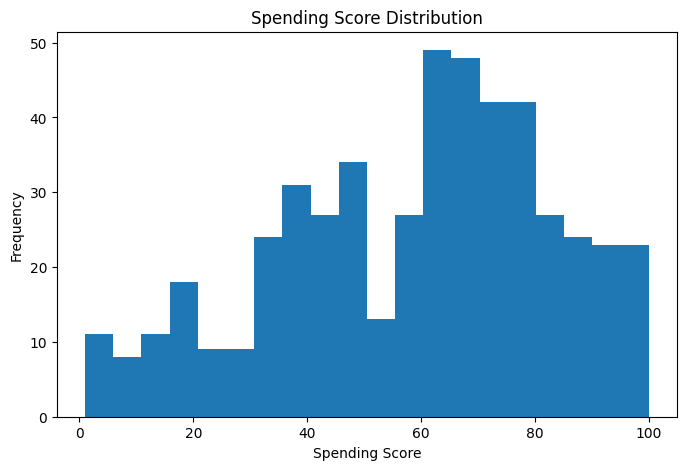

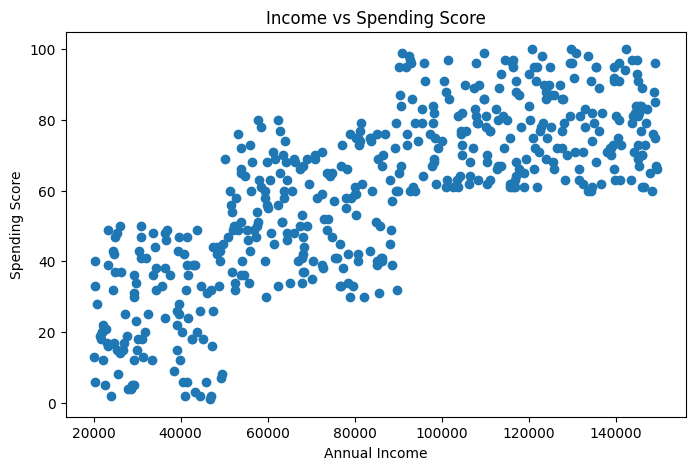

In [ ]:
#visulization
plt.figure(figsize=(8,5))
plt.hist(df['Annual_Income'], bins=20)
plt.title('Annual Income Distribution')
plt.xlabel('Income')
plt.ylabel('Frequency')
plt.show()

plt.figure(figsize=(8,5))
plt.hist(df['Spending_Score'], bins=20)
plt.title('Spending Score Distribution')
plt.xlabel('Spending Score')
plt.ylabel('Frequency')
plt.show()

plt.figure(figsize=(8,5))
plt.scatter(df['Annual_Income'], df['Spending_Score'])
plt.title('Income vs Spending Score')
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.show()

In [ ]:
#feature selection
X_cluster = df[['Annual_Income', 'Spending_Score', 'Purchases_Per_Month']]

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)


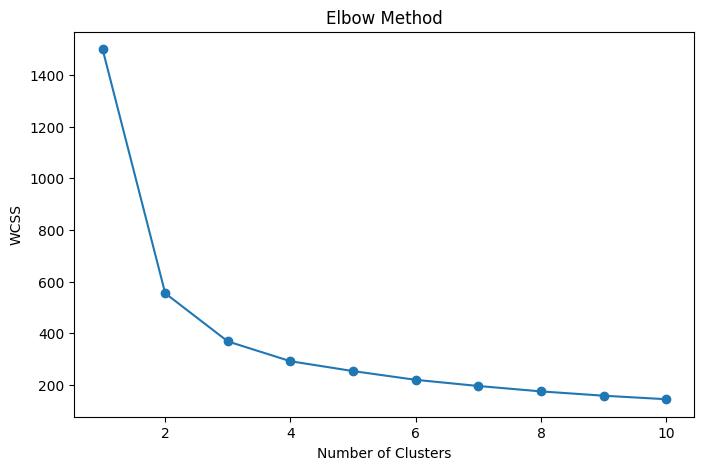

In [ ]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()


In [ ]:
#k-mean clustring
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

df['Cluster'] = clusters

print("\nCluster Counts")
print(df['Cluster'].value_counts())


Cluster Counts
Cluster
1    206
2    172
0    122
Name: count, dtype: int64


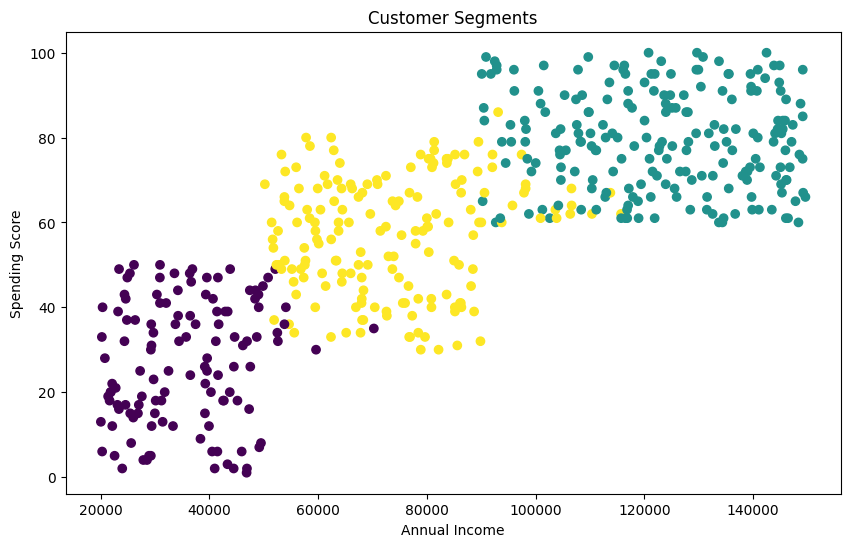

In [ ]:
plt.figure(figsize=(10,6))
plt.scatter(df['Annual_Income'], df['Spending_Score'], c=df['Cluster'])
plt.title('Customer Segments')
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.show()


In [ ]:
X = df[['Age', 'Annual_Income', 'Spending_Score', 'Purchases_Per_Month']]
y = df['Cluster']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [ ]:
scaler_knn = StandardScaler()

X_train = scaler_knn.fit_transform(X_train)
X_test = scaler_knn.transform(X_test)

In [ ]:
# TRAIN MODEL
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)


KNeighborsClassifier()

In [ ]:
y_pred = knn.predict(X_test)

In [ ]:
print("\nAccuracy:")
print(round(accuracy_score(y_test, y_pred) * 100, 2), "%")



Accuracy:
99.0 %


In [ ]:
print("\nClassification Report")
print(classification_report(y_test, y_pred))


Classification Report
              precision    recall  f1-score   support

           0       1.00      0.96      0.98        24
           1       1.00      1.00      1.00        38
           2       0.97      1.00      0.99        38

    accuracy                           0.99       100
   macro avg       0.99      0.99      0.99       100
weighted avg       0.99      0.99      0.99       100



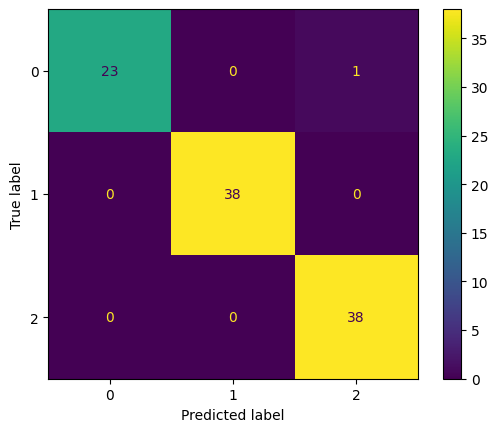

In [ ]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()


In [ ]:
print("\nCluster Summary")
display(df.groupby('Cluster').mean(numeric_only=True))


Cluster Summary


,Age,Annual_Income,Spending_Score,Purchases_Per_Month
Cluster,,,,
0,41.016393,35744.196721,27.163934,3.614754
1,41.451456,123195.747573,79.378641,14.320388
2,41.819767,73759.447674,56.959302,8.203488


In [ ]:
new_customer = pd.DataFrame({
    'Age':[40],
    'Annual_Income':[200000],
    'Spending_Score':[75],
    'Purchases_Per_Month':[15]
})

new_customer_scaled = scaler_knn.transform(new_customer)
prediction = knn.predict(new_customer_scaled)

print("\nPredicted Cluster:", prediction[0])


Predicted Cluster: 1
